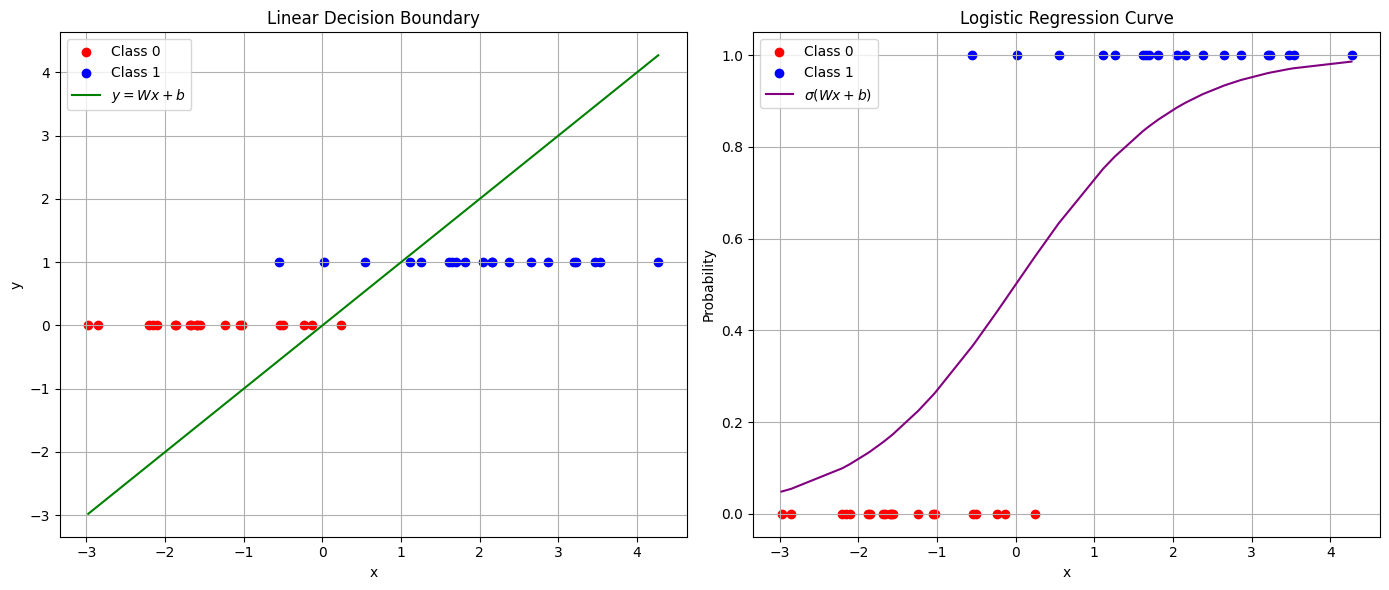

In [ ]:
# Generate some sample binary data in 1D
np.random.seed(0)
x_class0 = np.random.normal(loc=-2, scale=1, size=20)
x_class1 = np.random.normal(loc=2, scale=1, size=20)
y_class0 = np.zeros_like(x_class0)
y_class1 = np.ones_like(x_class1)

# Combine the data
x_values = np.concatenate([x_class0, x_class1])
y_values = np.concatenate([y_class0, y_class1])

# Sort the data (for visualization purposes)
sorted_indices = np.argsort(x_values)
x_values_sorted = x_values[sorted_indices]
y_values_sorted = y_values[sorted_indices]

# Define the weight and bias for the linear model
W = 1  # Slope
b = 0  # Intercept

# Calculate the linear model y = Wx + b
linear_decision_boundary = W * x_values_sorted + b

# Calculate the sigmoid curve sigma(Wx + b)
sigmoid_curve = 1 / (1 + np.exp(-linear_decision_boundary))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Linear Decision Boundary
axes[0].scatter(x_class0, y_class0, color='red', label='Class 0')
axes[0].scatter(x_class1, y_class1, color='blue', label='Class 1')
axes[0].plot(x_values_sorted, linear_decision_boundary, color='green', label=r'$y = Wx + b$')
axes[0].set_title("Linear Decision Boundary")
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Logistic Regression Curve
axes[1].scatter(x_class0, y_class0, color='red', label='Class 0')
axes[1].scatter(x_class1, y_class1, color='blue', label='Class 1')
axes[1].plot(x_values_sorted, sigmoid_curve, color='purple', label=r'$\sigma(Wx + b)$')
axes[1].set_title("Logistic Regression Curve")
axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


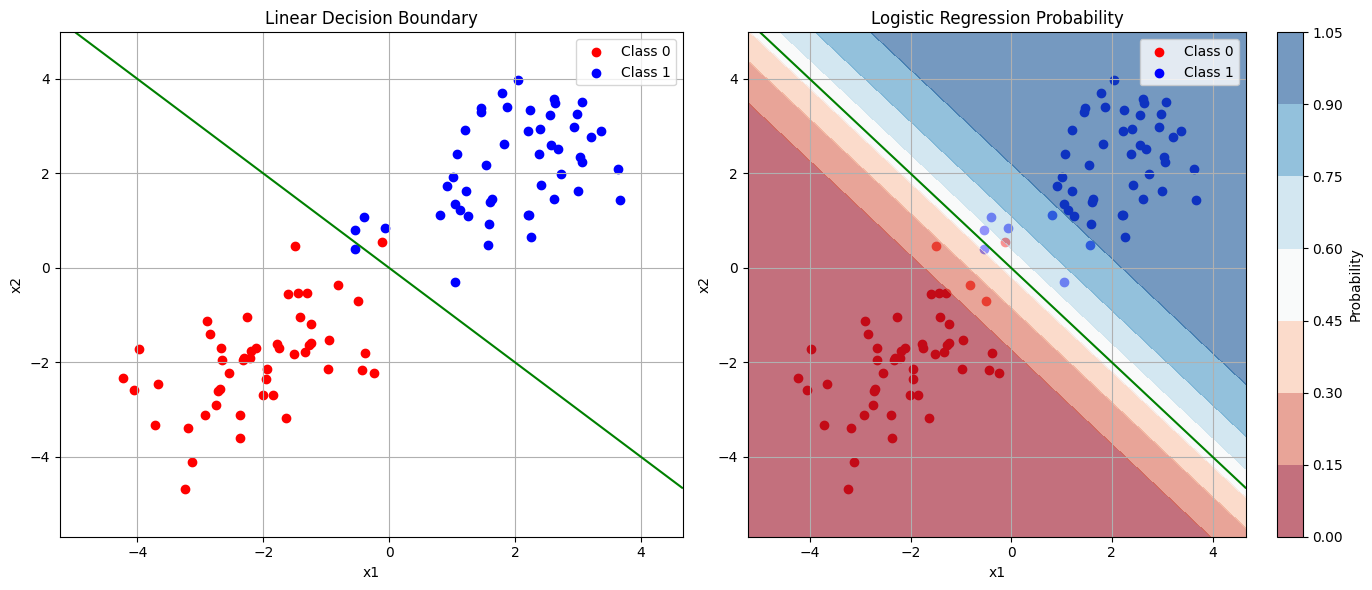

In [ ]:
# Generate some sample binary data in 2D
np.random.seed(0)
x_class0 = np.random.multivariate_normal(mean=[-2, -2], cov=[[1, 0.5], [0.5, 1]], size=50)
x_class1 = np.random.multivariate_normal(mean=[2, 2], cov=[[1, 0.5], [0.5, 1]], size=50)

# Combine the data
x_values = np.vstack((x_class0, x_class1))
y_values = np.hstack((np.zeros(50), np.ones(50)))

# Define the weight vector and bias for the linear model
W = np.array([1, 1])  # Example weights for the linear decision boundary
b = 0  # Example bias

# Calculate the linear decision boundary (z = W^T x + b)
z_values = np.dot(x_values, W) + b

# Create a grid of points in the input space for visualization
x_min, x_max = x_values[:, 0].min() - 1, x_values[:, 0].max() + 1
y_min, y_max = x_values[:, 1].min() - 1, x_values[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Calculate the linear decision boundary and sigmoid on the grid
Z_linear = W[0] * xx + W[1] * yy + b
Z_sigmoid = 1 / (1 + np.exp(-Z_linear))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Linear Decision Boundary
axes[0].scatter(x_class0[:, 0], x_class0[:, 1], color='red', label='Class 0')
axes[0].scatter(x_class1[:, 0], x_class1[:, 1], color='blue', label='Class 1')
axes[0].contour(xx, yy, Z_linear, levels=[0], colors='green')  # Decision boundary
axes[0].set_title("Linear Decision Boundary")
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Logistic Regression Probability
axes[1].scatter(x_class0[:, 0], x_class0[:, 1], color='red', label='Class 0')
axes[1].scatter(x_class1[:, 0], x_class1[:, 1], color='blue', label='Class 1')
contour = axes[1].contourf(xx, yy, Z_sigmoid, alpha=0.6, cmap='RdBu')
axes[1].contour(xx, yy, Z_sigmoid, levels=[0.5], colors='green')  # Decision boundary at 0.5 probability
axes[1].set_title("Logistic Regression Probability")
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].grid(True)
axes[1].legend()
fig.colorbar(contour, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()


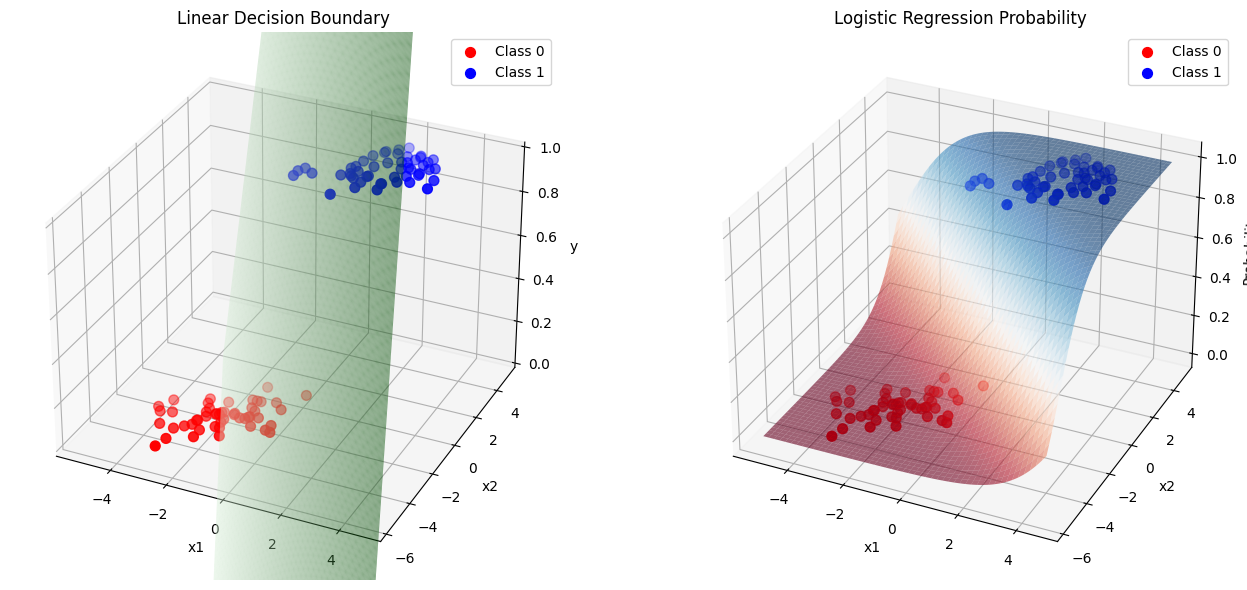

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap

azimuth = 115 + 180

# Plotting
fig = plt.figure(figsize=(14, 6))

# 3D Plot of the Linear Decision Boundary
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x_class0[:, 0], x_class0[:, 1], y_values[:50], color='red', label='Class 0', s=50)
ax1.scatter(x_class1[:, 0], x_class1[:, 1], y_values[50:], color='blue', label='Class 1', s=50)

# Create a gradient color based on the X and Y values
green_cmap = LinearSegmentedColormap.from_list('shades_of_green', ['#d9f2d9', '#004d00'])
gradient_color = (xx - xx.min()) / (xx.max() - xx.min())  # Normalize X values between 0 and 1
ax1.plot_surface(xx, yy, Z_linear, facecolors=green_cmap(gradient_color), alpha=0.5, rstride=1, cstride=1, linewidth=0, edgecolor='none')

ax1.set_title("Linear Decision Boundary")
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')
ax1.set_zlim(0, 1)
ax1.view_init(azim=azimuth)
ax1.legend()

# 3D Plot of the Logistic Regression Probability
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(x_class0[:, 0], x_class0[:, 1], y_values[:50], color='red', label='Class 0', s=50)
ax2.scatter(x_class1[:, 0], x_class1[:, 1], y_values[50:], color='blue', label='Class 1', s=50)
ax2.plot_surface(xx, yy, Z_sigmoid, cmap='RdBu', alpha=0.6)
ax2.set_title("Logistic Regression Probability")
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('Probability')
ax2.view_init(azim=azimuth)
ax2.legend()

plt.tight_layout()
plt.show()
